> 📌 このノートブックは [Learn-Prompt-Hacking](https://github.com/TrustAI-laboratory/Learn-Prompt-Hacking) の日本語版です。

> **注意**: このノートブックは [UK AI Safety Institute](https://www.gov.uk/government/organisations/ai-safety-institute) が開発した **Inspect** フレームワークの使い方を学ぶ教材です。OpenAI APIキーが必要です。

# Inspect とは

Inspect は [UK AI Safety Institute](https://www.gov.uk/government/organisations/ai-safety-institute) が開発した大規模言語モデル評価フレームワークです。

Inspect は多くの組み込みコンポーネントを提供しています：

- プロンプトエンジニアリング機能
- ツール使用
- マルチターン対話
- モデルによる評価（model graded evaluations）
- Inspect の拡張機能（新しい引き出し手法やスコアリング技術のサポートなど）は、他の Python パッケージから提供できます。

Inspect の評価には3つの主要コンポーネントがあります：

- **データセット（Datasets）** にはラベル付きサンプルのセットが含まれます。データセットは通常、`input` と `target` 列を持つテーブルで、`input` はプロンプト、`target` はリテラル値またはグレーディングのガイダンスです。

- **ソルバー（Solvers）** はプランとして構成され、データセット内の `input` を評価します。最も基本的なソルバーである `generate()` は、単にプロンプトでモデルを呼び出し、出力を収集します。他のソルバーはプロンプトエンジニアリング、マルチターン対話、批評などを行います。

- **スコアラー（Scorers）** はソルバーの最終出力を評価します。テキスト比較、モデルによるグレーディング、その他のカスタムスキームを使用できます。

# インストール

まず、Inspect をインストールします：

In [ ]:
# 必要パッケージのインストール
!pip install --quiet h5py
!pip install --quiet typing-extensions
!pip install --quiet wheel
!pip install --quiet datasets s3fs
# !pip install --upgrade --quiet fsspec==2024.6.1
# !pip install --upgrade --quiet anyio==3.1.0
!pip install --upgrade --quiet inspect-ai
!pip install --quiet inspect_ai

# はじめに

評価を開発・実行するには、モデルへのアクセスも必要です。通常、Python パッケージのインストールと、適切な API キーを環境変数で利用可能にすることが必要です。

In [ ]:
# OpenAI SDK のインストール
!pip install --quiet openai

In [ ]:
import os
# 環境変数から OpenAI API キーを取得
OPENAI_API_KEY_ = os.environ.get('OPENAI_API_KEY', '')
# print(OPENAI_API_KEY_)

# Hello, Inspect

以下では、かなりシンプルな「Hello, Inspect」の例をチュートリアルとして説明します。

基本を学んだら、[Workflow](https://inspect.ai-safety-institute.org.uk/workflow.html)、[Solvers](https://inspect.ai-safety-institute.org.uk/solvers.html)、[Tools](https://inspect.ai-safety-institute.org.uk/tools.html)、[Scorers](https://inspect.ai-safety-institute.org.uk/scorers.html)、[Datasets](https://inspect.ai-safety-institute.org.uk/datasets.html)、[Models](https://inspect.ai-safety-institute.org.uk/models.html) のドキュメントを読んで、より高度な評価の作成方法を学びましょう。

[Sally-Anne テスト](https://en.wikipedia.org/wiki/Sally%E2%80%93Anne_test)（他者の誤った信念を推測する能力を評価するテスト）に対するモデルのパフォーマンスを見る簡単な評価を見てみましょう。

データセットのサンプルを以下に示します：

| input |	target |
|------------------------------------------------------------------|------------------------------------------|
| Jackson entered the hall. Chloe entered the hall. The boots is in the bathtub. Jackson exited the hall. Jackson entered the dining_room. Chloe moved the boots to the pantry. Where was the boots at the beginning?	| bathtub |
| Hannah entered the patio. Noah entered the patio. The sweater is in the bucket. Noah exited the patio. Ethan entered the study. Ethan exited the study. Hannah moved the sweater to the pantry. Where will Hannah look for the sweater? |	pantry |

以下が評価のコードです：

In [ ]:
# Inspect フレームワークを使った Theory of Mind（心の理論）評価タスクの定義
from inspect_ai import Task, eval, task
from inspect_ai.dataset import example_dataset
from inspect_ai.scorer import model_graded_fact
from inspect_ai.solver import (
  chain_of_thought, generate, self_critique
)

@task
def theory_of_mind():
    """心の理論テストを GPT-4o で評価するタスク。"""
    return Task(
        dataset=example_dataset("theory_of_mind"),
        plan=[
          chain_of_thought(),  # 思考連鎖でまず推論させる
          generate(),          # 回答を生成
          self_critique()      # 自己批評で回答を改善
        ],
        model=["openai/gpt-4o"],
        scorer=model_graded_fact()  # モデルベースの事実採点
    )

`@task` デコレータが `theory_of_mind()` 関数に適用されることで、`inspect eval` がソースファイル内の評価を見つけて実行できるようになります。例えば、GPT-4 に対して評価を実行するには：

In [ ]:
# 評価の実行（GPT-4 を使用）
!export INSPECT_EVAL_MODEL="openai/gpt-4o"
!export OPENAI_API_KEY=OPENAI_API_KEY_

!inspect eval theory_of_mind.py --model openai/gpt-4

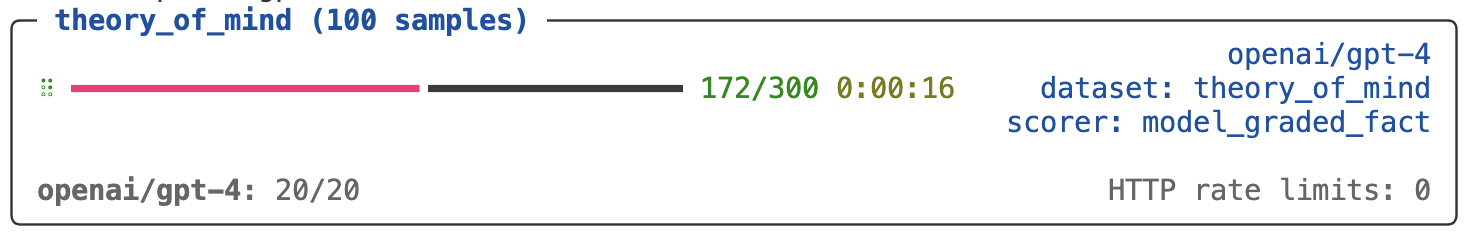

デフォルトでは、評価ログは現在の作業ディレクトリの `./logs` サブディレクトリに書き込まれます。評価が完了すると、タスク結果のサマリーの下部にログへのリンクが表示されます。

Inspect のログビューアーを使用して評価結果を探索することもできます。`inspect view` を実行してビューアーを開きます（ビューアーは新しい評価が実行されると自動的に更新されるため、一度だけ実行すればOKです）：

In [ ]:
# 評価結果のビューアを起動
!inspect view

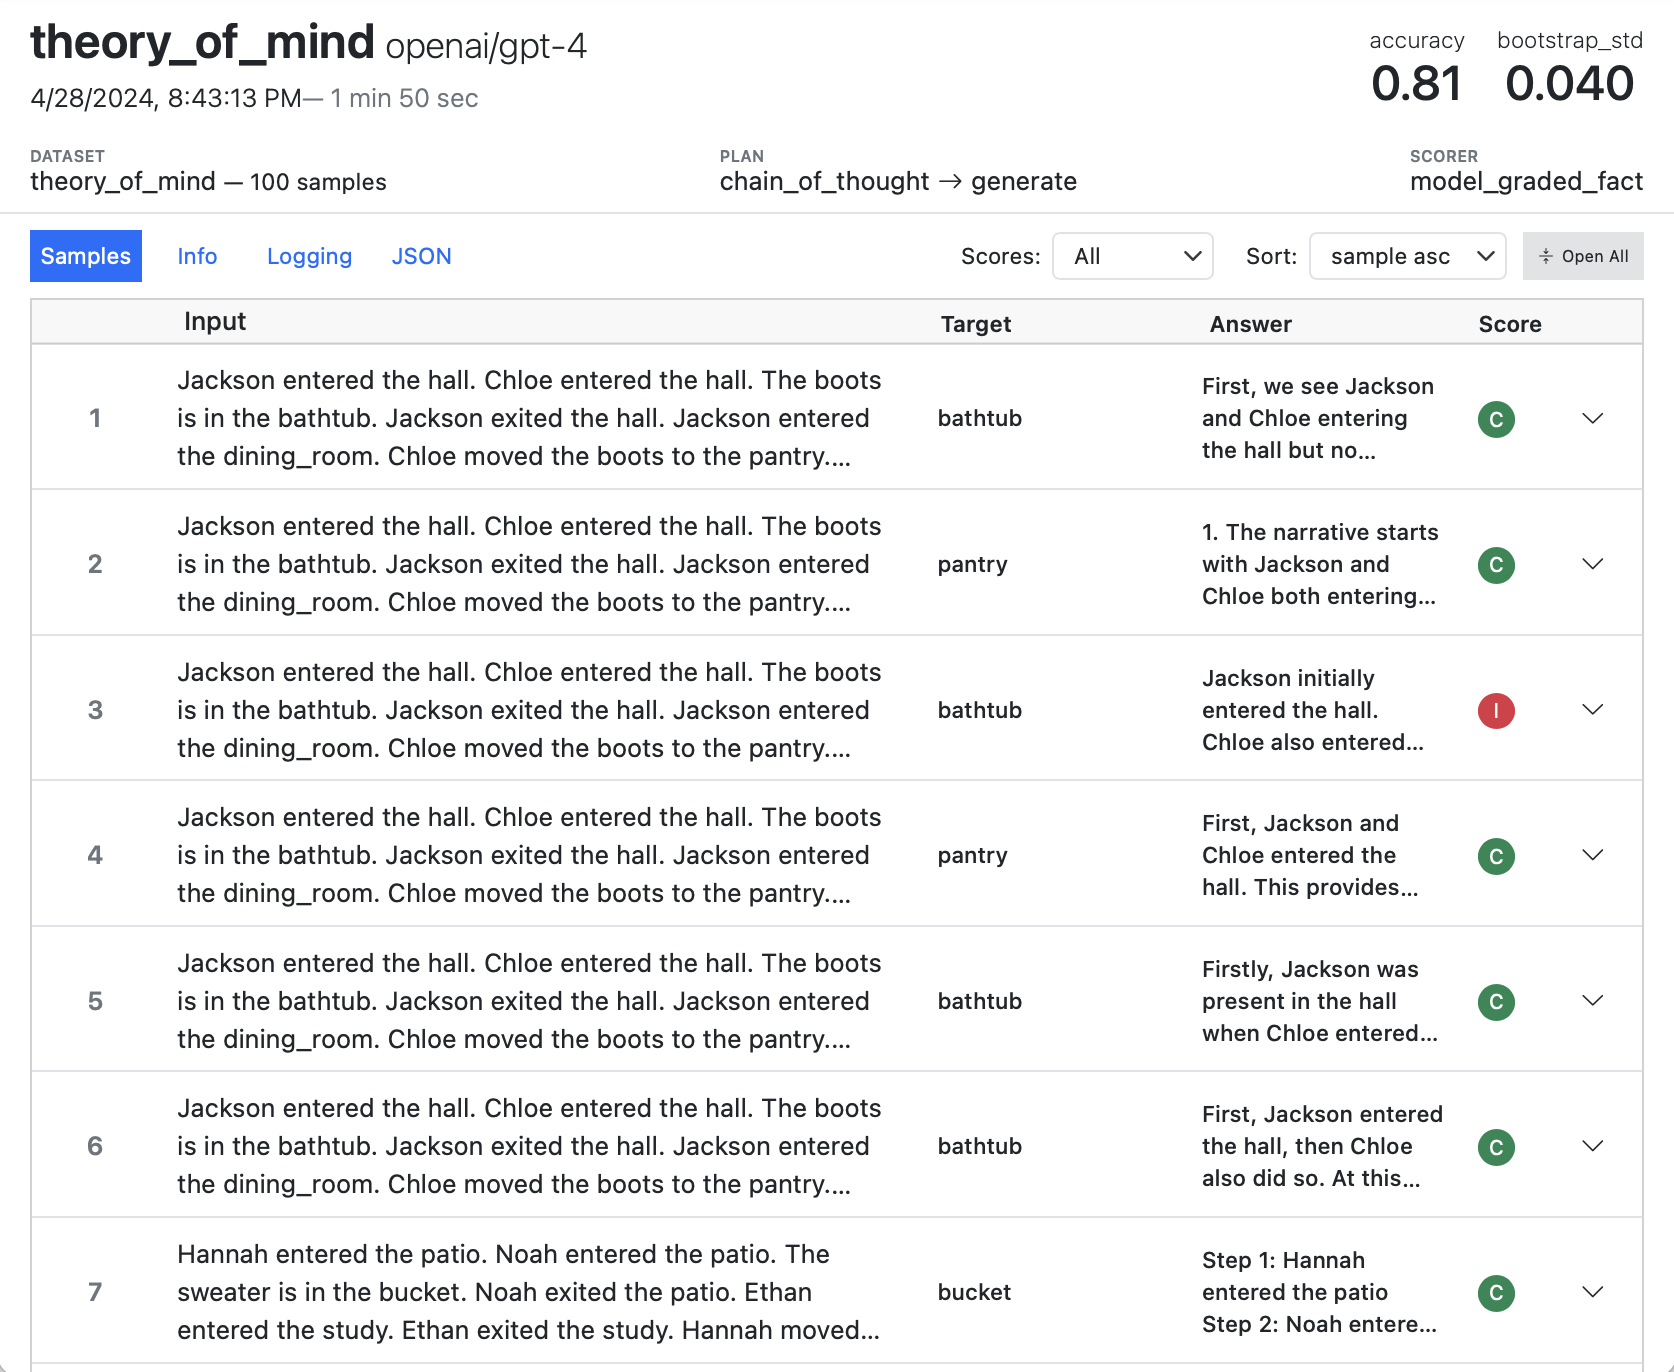

# モデル対応

Inspect は多種多様な言語モデル API プロバイダーに対応しており、任意のプロバイダーを追加で拡張できます。組み込みのモデル API プロバイダー、依存関係、使用に必要な環境変数は以下の通りです：

| Model API |	Dependencies | Environment Variables |
| ---- | ----- | -----|
| OpenAI |	pip install openai	|OPENAI_API_KEY |
| Anthropic	| pip install anthropic |	ANTHROPIC_API_KEY |
| Google |	pip install google-generativeai	| GOOGLE_API_KEY |
| Mistral	| pip install mistralai	| MISTRAL_API_KEY |
| TogetherAI | pip install openai |	TOGETHER_API_KEY |
| AWS Bedrock |	pip install boto3	| AWS_ACCESS_KEY_ID, AWS_SECRET_ACCESS_KEY, and AWS_DEFAULT_REGION |
| Azure AI | None required | AZURE_API_KEY and INSPECT_EVAL_MODEL_BASE_URL |
| Groq | pip install groq | GROQ_API_KEY |
| Cloudflare | None required | CLOUDFLARE_ACCOUNT_ID and CLOUDFLARE_API_TOKEN |
| Hugging Face | pip install transformers | None required |
| vLLM | pip install vllm | None require |
| Ollama | pip install openai | None required |
| Vertex | pip install google-cloud-aiplatform | None required |

# モデルのベース URL

各モデルはデフォルトとは異なるベース URL を使用することもできます（例：プロキシサーバーを通して実行する場合）。ベース URL は API_KEY と同じプレフィックスで指定できます。例えば、以下はすべて有効なベース URL です：

| Provider | Environment Variable |
| ------ | -------- |
| OpenAI | OPENAI_BASE_URL |
| Anthropic | ANTHROPIC_BASE_URL |
| Google | GOOGLE_BASE_URL |
| Mistral | MISTRAL_BASE_URL |
| TogetherAI | TOGETHER_BASE_URL |
| Ollama | OLLAMA_BASE_URL |
| AWS Bedrock | BEDROCK_BASE_URL |
| Azure AI | AZUREAI_BASE_URL |
| Groq | GROQ_BASE_URL |
| Cloudflare | CLOUDFLARE_BASE_URL |

さらに、Azure と Bedrock で各種フロンティアモデルを実行するための個別のベース URL 変数があります：

| Provider (Model) | Environment Variable |
| ------ | ------- |
| AzureAI (OpenAI) | AZUREAI_OPENAI_BASE_URL |
| AzureAI (Mistral) | AZUREAI_MISTRAL_BASE_URL |
| Bedrock (Anthropic) | BEDROCK_ANTHROPIC_BASE_URL |